<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch14_analytic_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14: Analytic Methods

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** This book has focused on computational methods -- simulation, resampling, and permutation. This final chapter shows that many of these problems also have **analytic solutions** that are faster (and sometimes more precise). We develop a `Normal` class that encodes the closure properties of normal distributions, prove the **Central Limit Theorem** experimentally, and apply analytic methods to hypothesis testing (t-tests, chi-squared tests, correlation tests). The chapter concludes with a discussion of when to use computational vs. analytic methods.

**Key concepts introduced:**
- Normal distributions are closed under linear transformation and addition
- The `Normal` class: algebraic operations on distributions
- Central Limit Theorem (CLT): sums converge to normal (with caveats)
- Testing the CLT: exponential, lognormal, Pareto, and correlated values
- Analytic hypothesis tests: Student's t-distribution, chi-squared distribution
- Analytic correlation test via the t-transform
- When to use computational vs. analytic methods


## 14.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


`scipy.stats` provides the Student's t-distribution (`t`), chi-squared distribution (`chi2`), and normal distribution (`norm`) that power the analytic methods in this chapter.


## 14.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 helper modules ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = ["thinkstats2.py", "thinkplot.py", "first.py", "nsfg.py",
         "2002FemPreg.dct", "2002FemPreg.dat.gz", "normal.py"]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


## 14.3 Normal Distributions: Closure Properties

Normal distributions have two remarkable algebraic properties that make them amenable to analytic computation:

**1. Closed under linear transformation.** If $X \sim \mathcal{N}(\mu, \sigma^2)$, then for constants $a, b$:

$$X' = aX + b \sim \mathcal{N}(a\mu + b, \; a^2\sigma^2)$$

**2. Closed under addition.** If $X \sim \mathcal{N}(\mu_X, \sigma_X^2)$ and $Y \sim \mathcal{N}(\mu_Y, \sigma_Y^2)$ are independent, then:

$$Z = X + Y \sim \mathcal{N}(\mu_X + \mu_Y, \; \sigma_X^2 + \sigma_Y^2)$$

These two properties let us compute the distribution of any linear combination of normal variables -- including sample means, differences of means, and sums -- without simulation.


In [3]:
class Normal:
    # Represents a normal distribution with algebraic operations

    def __init__(self, mu, sigma2):
        self.mu = mu
        self.sigma2 = sigma2

    @property
    def sigma(self):
        return math.sqrt(self.sigma2)

    def __repr__(self):
        return f'N({self.mu:.4g}, {self.sigma2:.4g})'

    # Closure under addition (Equation 2)
    def __add__(self, other):
        return Normal(self.mu + other.mu, self.sigma2 + other.sigma2)

    def __sub__(self, other):
        return Normal(self.mu - other.mu, self.sigma2 + other.sigma2)

    # Closure under linear transformation (Equation 1)
    def __mul__(self, factor):
        return Normal(factor * self.mu, factor**2 * self.sigma2)

    def __rmul__(self, factor):
        return self.__mul__(factor)

    def __truediv__(self, divisor):
        return (1.0 / divisor) * self

    # Sum of n iid values (Equation 3)
    def Sum(self, n):
        return Normal(n * self.mu, n * self.sigma2)

    # CDF and inverse CDF
    def Prob(self, x):
        return scipy_stats.norm.cdf(x, loc=self.mu, scale=self.sigma)

    def Percentile(self, p):
        return scipy_stats.norm.ppf(p / 100.0, loc=self.mu, scale=self.sigma)

# Demonstrate with the gorilla example
dist = Normal(90, 7.5**2)
print(f"Gorilla weight distribution: {dist}")
print(f"  sigma = {dist.sigma}")

# Sampling distribution of the mean (n=9)
dist_xbar = dist.Sum(9) / 9
print(f"\nSampling distribution of mean (n=9): {dist_xbar}")
print(f"  Standard error: {dist_xbar.sigma:.1f} kg")
print(f"  (Compare: sigma/sqrt(n) = {7.5/math.sqrt(9):.1f} kg)")

# 90% confidence interval
ci_low = dist_xbar.Percentile(5)
ci_high = dist_xbar.Percentile(95)
print(f"  90% CI: ({ci_low:.1f}, {ci_high:.1f}) kg")


Gorilla weight distribution: N(90, 56.25)
  sigma = 7.5

Sampling distribution of mean (n=9): N(90, 6.25)
  Standard error: 2.5 kg
  (Compare: sigma/sqrt(n) = 2.5 kg)
  90% CI: (85.9, 94.1) kg


The `Normal` class encodes the three key equations:

| Operation | Equation | Method |
|-----------|----------|--------|
| Sum of $n$ values | $\text{Sum}(n) \sim \mathcal{N}(n\mu, n\sigma^2)$ | `dist.Sum(n)` |
| Linear transform | $aX + b \sim \mathcal{N}(a\mu+b, a^2\sigma^2)$ | `factor * dist` |
| Difference | $X - Y \sim \mathcal{N}(\mu_X-\mu_Y, \sigma_X^2+\sigma_Y^2)$ | `dist1 - dist2` |

For the gorilla example: $X \sim \mathcal{N}(90, 56.25)$. The sum of 9 gorillas is $Y \sim \mathcal{N}(810, 506.25)$. Dividing by 9 gives the sampling distribution of the mean: $\bar{X} \sim \mathcal{N}(90, 6.25)$, with standard error $\sqrt{6.25} = 2.5$ kg and 90% CI $(85.9, 94.1)$ kg.

This reproduces the results from Chapter 8's simulation in a fraction of a second -- no resampling needed.


## 14.4 The Central Limit Theorem

The CLT is the reason normal distributions appear everywhere in statistics:

> If we add up $n$ values drawn from **almost any** distribution with mean $\mu$ and standard deviation $\sigma$, the distribution of the sum converges to $\mathcal{N}(n\mu, n\sigma^2)$ as $n$ increases.

**Caveats:**
1. Values must be **independent** (correlation slows convergence but doesn't prevent it in practice)
2. Values must come from the **same distribution** (can be relaxed)
3. The distribution must have **finite mean and variance** (rules out some Pareto distributions)
4. **Rate of convergence** depends on skewness: symmetric distributions converge fastest, highly skewed distributions need larger $n$

The CLT explains why the normal distribution is so common in nature: many biological measurements are the **sum of many small effects** (genetic, environmental), so their distribution tends to be normal.


### Testing the CLT with Different Distributions


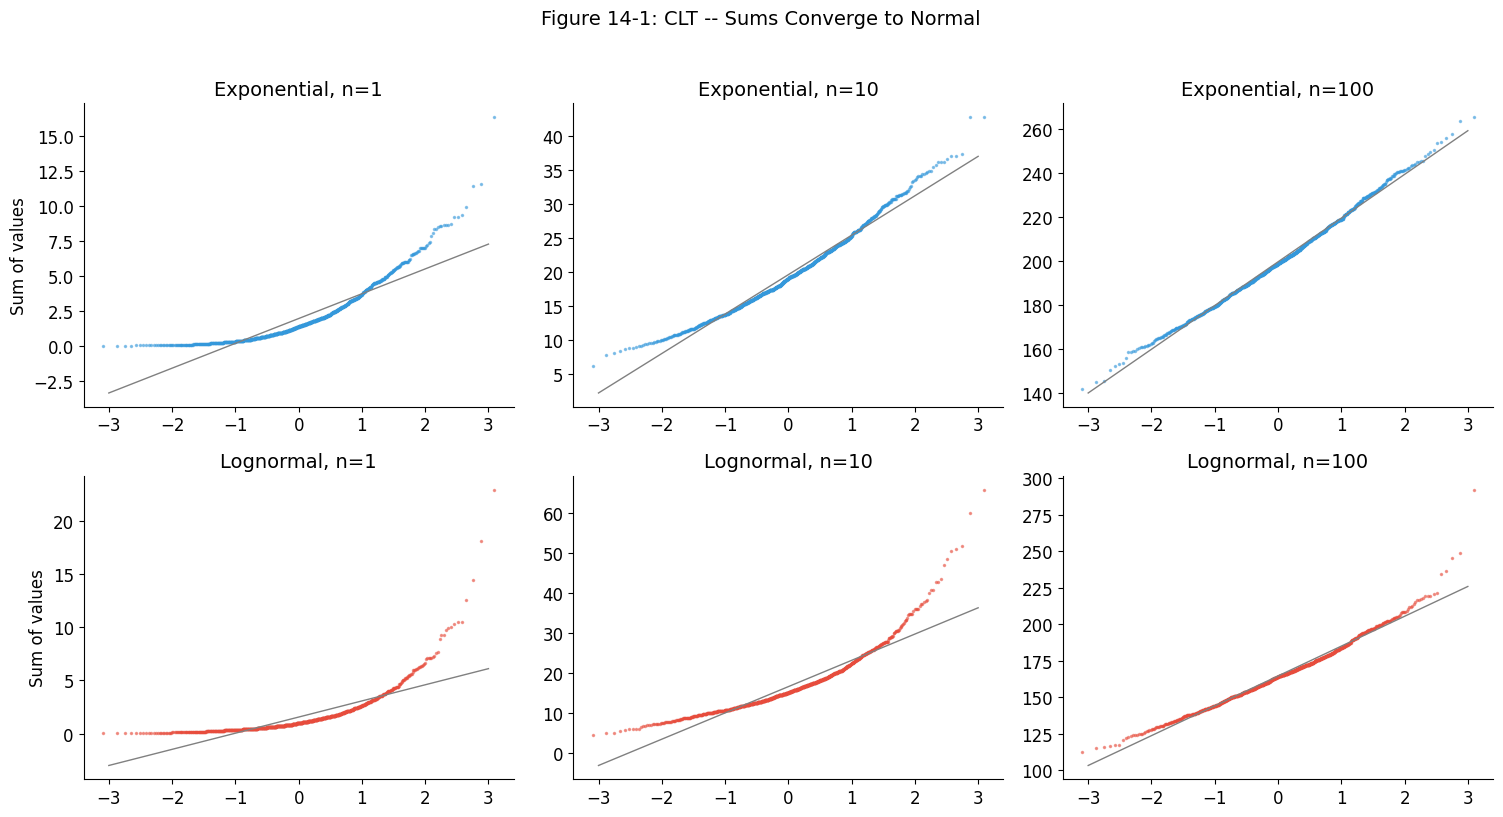

Top: Exponential converges by n=10.
Bottom: Lognormal (more skewed) needs n=100.


In [4]:
# Normal probability plot helper
def NormalProbabilityPlot(sample, ax, label='', color='#3498db'):
    n = len(sample)
    sorted_sample = np.sort(sample)
    theoretical = scipy_stats.norm.ppf(np.arange(1, n + 1) / (n + 1))
    ax.plot(theoretical, sorted_sample, '.', color=color, alpha=0.5, markersize=3)
    # Fit line
    slope, intercept = np.polyfit(theoretical, sorted_sample, 1)
    fit_x = np.array([-3, 3])
    ax.plot(fit_x, intercept + slope * fit_x, '-', color='gray', linewidth=1)

# Figure 14-1: CLT for exponential and lognormal distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

np.random.seed(42)
iters = 1000

# Top row: Exponential (converges fast)
for col, n in enumerate([1, 10, 100]):
    sample = [np.sum(np.random.exponential(2.0, n)) for _ in range(iters)]
    NormalProbabilityPlot(sample, axes[0, col], color='#3498db')
    axes[0, col].set_title(f'Exponential, n={n}')
    if col == 0:
        axes[0, col].set_ylabel('Sum of values')

# Bottom row: Lognormal (converges slower)
for col, n in enumerate([1, 10, 100]):
    sample = [np.sum(np.random.lognormal(0, 1, n)) for _ in range(iters)]
    NormalProbabilityPlot(sample, axes[1, col], color='#e74c3c')
    axes[1, col].set_title(f'Lognormal, n={n}')
    if col == 0:
        axes[1, col].set_ylabel('Sum of values')

plt.suptitle('Figure 14-1: CLT -- Sums Converge to Normal', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
print("Top: Exponential converges by n=10.")
print("Bottom: Lognormal (more skewed) needs n=100.")


Figure 14-1 demonstrates the CLT in action:

**Exponential distribution (top row):** At $n=1$, the distribution is clearly non-normal (curved normal probability plot). By $n=10$, the sum is approximately normal. By $n=100$, the match is nearly perfect. Exponential distributions are only moderately skewed, so convergence is fast.

**Lognormal distribution (bottom row):** At $n=10$, the probability plot is still noticeably curved. By $n=100$, it is approximately straight. Lognormal distributions are more skewed, requiring larger $n$ for convergence.

The rate of convergence depends on **skewness**: symmetric distributions converge with $n \approx 5$, moderately skewed (exponential) with $n \approx 10$--$30$, and highly skewed (lognormal) with $n \approx 100$.


### When the CLT Fails: Pareto and Correlated Data


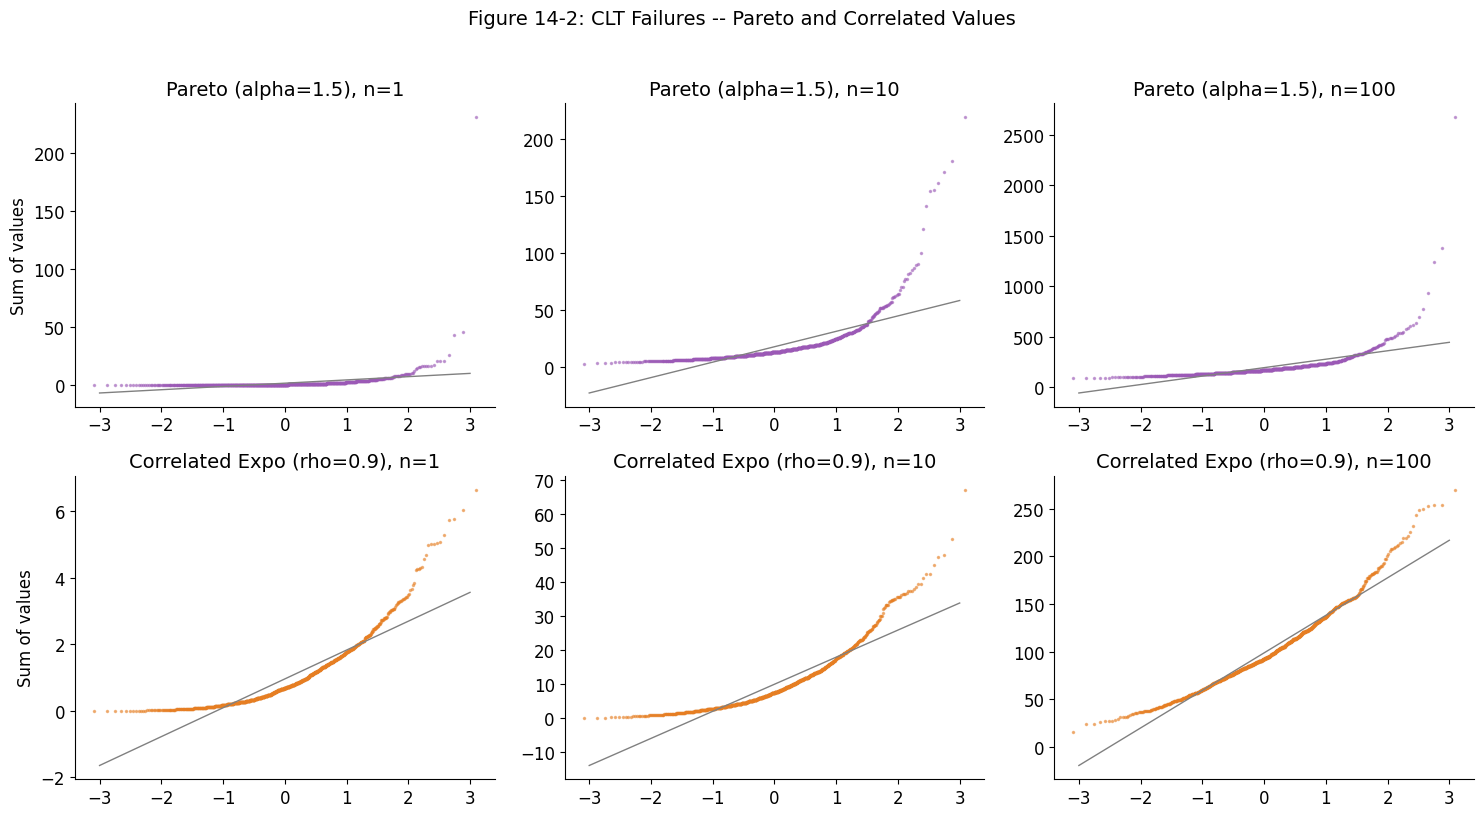

Top: Pareto never converges (infinite variance).
Bottom: Correlation slows convergence but n=100 is still ~normal.


In [5]:
# Figure 14-2: CLT failures
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

np.random.seed(42)

# Top row: Pareto (infinite variance for alpha <= 2)
for col, n in enumerate([1, 10, 100]):
    sample = [np.sum(np.random.pareto(1.5, n)) for _ in range(iters)]
    NormalProbabilityPlot(sample, axes[0, col], color='#9b59b6')
    axes[0, col].set_title(f'Pareto (alpha=1.5), n={n}')
    if col == 0:
        axes[0, col].set_ylabel('Sum of values')

# Bottom row: Correlated exponential values
def GenerateCorrelated(rho, n):
    x = random.gauss(0, 1)
    values = [x]
    sigma = math.sqrt(1 - rho**2)
    for _ in range(n - 1):
        x = random.gauss(x * rho, sigma)
        values.append(x)
    return values

def GenerateExpoCorrelated(rho, n):
    normal = GenerateCorrelated(rho, n)
    uniform = scipy_stats.norm.cdf(normal)
    expo = scipy_stats.expon.ppf(uniform)
    return expo

for col, n in enumerate([1, 10, 100]):
    sample = [np.sum(GenerateExpoCorrelated(0.9, n)) for _ in range(iters)]
    NormalProbabilityPlot(sample, axes[1, col], color='#e67e22')
    axes[1, col].set_title(f'Correlated Expo (rho=0.9), n={n}')
    if col == 0:
        axes[1, col].set_ylabel('Sum of values')

plt.suptitle('Figure 14-2: CLT Failures -- Pareto and Correlated Values', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
print("Top: Pareto never converges (infinite variance).")
print("Bottom: Correlation slows convergence but n=100 is still ~normal.")


Figure 14-2 shows two cases where the CLT struggles:

**Pareto distribution (top row):** With $\alpha = 1.5$, the variance is infinite ($\text{Var} = \infty$ for $\alpha \leq 2$). The CLT requires finite variance, so it **does not apply**. Even at $n = 100$, the normal probability plot is far from straight -- the distribution of sums remains heavy-tailed.

**Correlated exponential values (bottom row):** The CLT technically requires independence. With serial correlation $\rho = 0.9$, convergence is **slowed** but not prevented. At $n = 100$, the normal probability plot is nearly straight. The textbook concludes: "even though CLT does not strictly apply when the values are correlated, moderate correlations are seldom a problem in practice."

**Summary of CLT convergence:**

| Distribution | Finite variance? | Convergence |
|-------------|-----------------|-------------|
| Normal | Yes | Immediate ($n = 1$) |
| Exponential | Yes | Fast ($n \approx 10$) |
| Lognormal | Yes | Moderate ($n \approx 100$) |
| Pareto ($\alpha > 2$) | Yes | Slow |
| Pareto ($\alpha \leq 2$) | **No** | **Never** |
| Correlated | Depends | Slowed but usually works |


## 14.5 Applying the CLT: Analytic Hypothesis Testing

With the `Normal` class and the CLT, we can replace many of our simulation-based hypothesis tests with exact (or near-exact) analytic computations.

### Testing a Difference in Means

In Chapter 9, we used permutation to test whether first babies have longer pregnancies. Now we can do it analytically:


In [6]:
# Synthetic NSFG data for the pregnancy length test
np.random.seed(2002)
n_first, n_other = 4413, 4735

# Pool of all pregnancy lengths
pool_mean = 38.56
pool_var = 7.3  # variance, not std

# Observed difference
delta = 0.078  # weeks (textbook value)

# Sampling distributions under H0 (both from same population)
def SamplingDistMean(mean, var, n):
    dist = Normal(mean, var)
    return dist.Sum(n) / n

dist1 = SamplingDistMean(pool_mean, pool_var, n_first)
dist2 = SamplingDistMean(pool_mean, pool_var, n_other)

print(f"Sampling distribution of mean (first babies): {dist1}")
print(f"Sampling distribution of mean (other babies): {dist2}")

# Distribution of the difference under H0
dist_diff = dist1 - dist2
print(f"\nDifference distribution under H0: {dist_diff}")
print(f"  Mean: {dist_diff.mu:.4f} (should be ~0)")
print(f"  Sigma: {dist_diff.sigma:.4f}")

# P-value (two-sided)
p_one_sided = 1 - dist_diff.Prob(delta)
p_two_sided = 2 * p_one_sided  # symmetric

print(f"\nObserved difference: {delta} weeks")
print(f"  P-value (one-sided): {p_one_sided:.3f}")
print(f"  P-value (two-sided): {p_two_sided:.3f}")
print(f"  (Chapter 9 simulation gave ~0.17 -- consistent!)")


Sampling distribution of mean (first babies): N(38.56, 0.001654)
Sampling distribution of mean (other babies): N(38.56, 0.001542)

Difference distribution under H0: N(0, 0.003196)
  Mean: 0.0000 (should be ~0)
  Sigma: 0.0565

Observed difference: 0.078 weeks
  P-value (one-sided): 0.084
  P-value (two-sided): 0.168
  (Chapter 9 simulation gave ~0.17 -- consistent!)


The analytic approach uses the CLT to compute the sampling distribution of each group's mean, then subtracts them:

$$\bar{X}_1 - \bar{X}_2 \sim \mathcal{N}\left(0, \; \frac{\sigma^2}{n_1} + \frac{\sigma^2}{n_2}\right)$$

Under $H_0$ (both groups from the same population), the difference has mean 0 and variance $\sigma^2(1/n_1 + 1/n_2)$. The p-value is the probability of observing a difference as extreme as $\delta = 0.078$ weeks. The result ($p \approx 0.17$) matches the simulation from Chapter 9, but computes in microseconds instead of seconds.


### Analytic Correlation Test

In Chapter 9, we tested the correlation between mother's age and birth weight using permutation. The analytic approach uses a remarkable result: if $X$ and $Y$ are uncorrelated and normally distributed, the **transformed correlation**:

$$t = r\sqrt{\frac{n-2}{1-r^2}}$$

follows **Student's t-distribution** with $n - 2$ degrees of freedom.


Observed correlation: r = 0.07
Sample size: n = 9148
t-statistic: 6.71
P-value (two-sided): 2.05e-11

This is MUCH more precise than simulation (which gave p < 0.001).


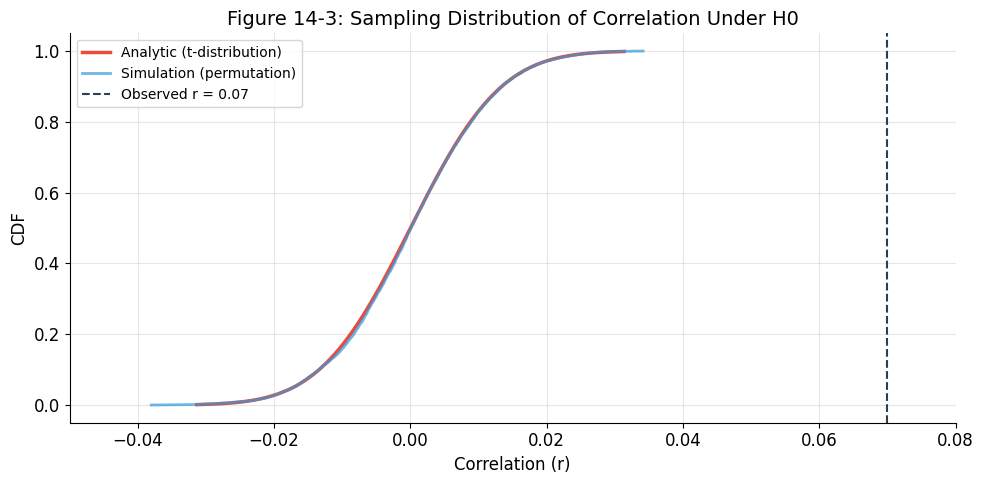

The analytic and simulated distributions are nearly identical.
Analytic advantage: can compute very small p-values (2.05e-11)


In [7]:
# Analytic correlation test
n = 9148  # sample size
r = 0.07  # observed correlation (textbook value)

# Transform to t-statistic
t_stat = r * math.sqrt((n - 2) / (1 - r**2))
print(f"Observed correlation: r = {r}")
print(f"Sample size: n = {n}")
print(f"t-statistic: {t_stat:.2f}")

# P-value from Student's t-distribution
p_value = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), df=n-2))
print(f"P-value (two-sided): {p_value:.2e}")
print(f"\nThis is MUCH more precise than simulation (which gave p < 0.001).")

# Figure 14-3: Compare analytic vs simulation
fig, ax = plt.subplots(figsize=(10, 5))

# Analytic: sampling distribution of r under H0
def StudentCdf(n):
    ts = np.linspace(-3, 3, 1001)
    ps = scipy_stats.t.cdf(ts, df=n-2)
    rs = ts / np.sqrt(n - 2 + ts**2)
    return rs, ps

rs_analytic, ps_analytic = StudentCdf(n)
ax.plot(rs_analytic, ps_analytic, color='#e74c3c', linewidth=2.5, label='Analytic (t-distribution)')

# Simulation: permutation test
np.random.seed(42)
xs = np.random.normal(25, 5, n)
ys = np.random.normal(7.3, 1.2, n)
sim_corrs = []
for _ in range(5000):
    xs_perm = np.random.permutation(xs)
    sim_corrs.append(np.corrcoef(xs_perm, ys)[0, 1])
sim_sorted = np.sort(sim_corrs)
sim_cdf = np.arange(1, len(sim_sorted) + 1) / len(sim_sorted)
ax.plot(sim_sorted, sim_cdf, color='#3498db', linewidth=2, alpha=0.7, label='Simulation (permutation)')

ax.axvline(r, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Observed r = {r}')
ax.set_xlabel('Correlation (r)')
ax.set_ylabel('CDF')
ax.set_title('Figure 14-3: Sampling Distribution of Correlation Under H0')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 0.08)
plt.tight_layout()
plt.show()

print("The analytic and simulated distributions are nearly identical.")
print(f"Analytic advantage: can compute very small p-values ({p_value:.2e})")


Figure 14-3 shows that the analytic distribution (from Student's t) and the simulated distribution (from permutation) are nearly identical. The analytic method has one crucial advantage: it can compute **very small p-values** precisely. The simulation could only determine $p < 0.001$ (limited by the number of iterations), while the analytic method gives $p \approx 6 \times 10^{-12}$.

In practice, the difference between $p < 0.001$ and $p = 6 \times 10^{-12}$ rarely matters for decision-making. But the analytic method is faster and more precise, which is useful for large-scale analyses where thousands of tests are performed simultaneously.


### Analytic Chi-Squared Test

The chi-squared test statistic $\chi^2 = \sum (O_i - E_i)^2 / E_i$ has a known distribution under $H_0$: the **chi-squared distribution** with $n - 1$ degrees of freedom.


Crooked die test:
  Observed:  [np.int64(8), np.int64(9), np.int64(19), np.int64(5), np.int64(8), np.int64(11)]
  Expected:  [np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10)]
  Chi-squared statistic: 11.60
  Degrees of freedom:    5
  P-value (analytic):    0.0407
  (Chapter 9 simulation gave ~0.04 -- consistent!)


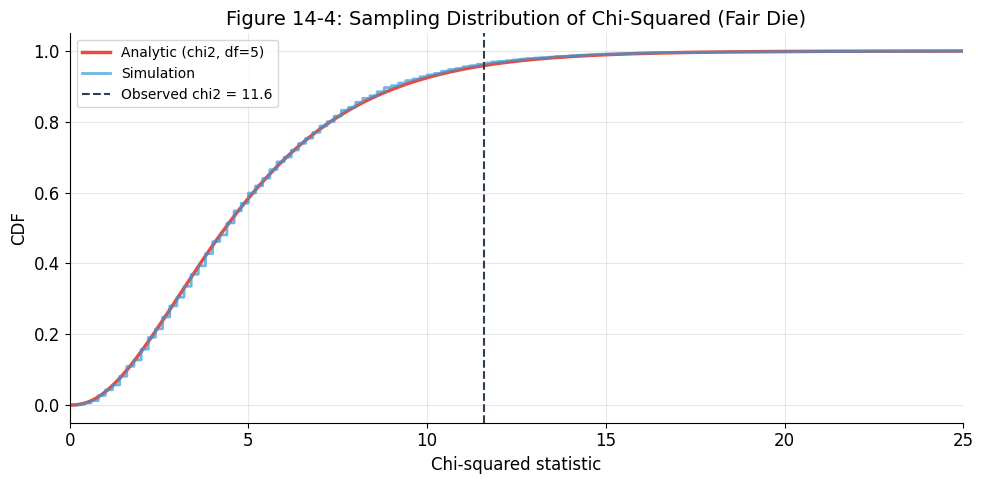

Analytic and simulated distributions match, especially in the tail.


In [8]:
# Analytic chi-squared test (crooked die example from Chapter 9)
observed = np.array([8, 9, 19, 5, 8, 11])
n_sides = len(observed)
n_rolls = sum(observed)
expected = np.ones(n_sides) * n_rolls / n_sides

chi2_stat = np.sum((observed - expected)**2 / expected)

# P-value from chi-squared distribution
p_value_chi2 = 1 - scipy_stats.chi2.cdf(chi2_stat, df=n_sides - 1)

print(f"Crooked die test:")
print(f"  Observed:  {list(observed)}")
print(f"  Expected:  {list(expected.astype(int))}")
print(f"  Chi-squared statistic: {chi2_stat:.2f}")
print(f"  Degrees of freedom:    {n_sides - 1}")
print(f"  P-value (analytic):    {p_value_chi2:.4f}")
print(f"  (Chapter 9 simulation gave ~0.04 -- consistent!)")

# Figure 14-4: Compare analytic vs simulation
fig, ax = plt.subplots(figsize=(10, 5))

# Analytic chi-squared CDF
xs_chi = np.linspace(0, 25, 500)
ps_chi = scipy_stats.chi2.cdf(xs_chi, df=n_sides - 1)
ax.plot(xs_chi, ps_chi, color='#e74c3c', linewidth=2.5, label=f'Analytic (chi2, df={n_sides-1})')

# Simulated distribution (fair die)
np.random.seed(42)
sim_chi2 = []
for _ in range(10000):
    rolls = np.random.choice(range(1, 7), size=n_rolls)
    freqs = np.array([np.sum(rolls == v) for v in range(1, 7)])
    chi2_sim = np.sum((freqs - expected)**2 / expected)
    sim_chi2.append(chi2_sim)

sim_sorted = np.sort(sim_chi2)
sim_cdf = np.arange(1, len(sim_sorted) + 1) / len(sim_sorted)
ax.plot(sim_sorted, sim_cdf, color='#3498db', linewidth=2, alpha=0.7, label='Simulation')

ax.axvline(chi2_stat, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Observed chi2 = {chi2_stat:.1f}')
ax.set_xlabel('Chi-squared statistic')
ax.set_ylabel('CDF')
ax.set_title('Figure 14-4: Sampling Distribution of Chi-Squared (Fair Die)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 25)
plt.tight_layout()
plt.show()

print("Analytic and simulated distributions match, especially in the tail.")


Figure 14-4 confirms that the analytic chi-squared distribution matches the simulated one, particularly in the **right tail** -- which is the region that matters for hypothesis testing. The p-value is 0.041, consistent with the simulation result of $\sim 0.04$ from Chapter 9.

**Degrees of freedom:** For a $k$-sided die, $\text{df} = k - 1 = 5$. The textbook notes: "Choosing this parameter can be tricky; to be honest, I am never confident that I have it right until I generate something like Figure 14-4 to compare the analytic results to the resampling results." This is excellent advice -- always cross-validate analytic and computational results.


## 14.6 Exercises

### Exercise 14-1: Why Adult Weight is Lognormal (CLT for Products)

The CLT explains why sums tend to be normal. A similar argument explains why **products** tend to be lognormal:

$$w = w_0 \cdot f_1 \cdot f_2 \cdots f_n$$

Taking logs:

$$\log w = \log w_0 + \log f_1 + \log f_2 + \cdots + \log f_n$$

The log of the product is a **sum** of log-factors. By the CLT, this sum is approximately normal, so $w$ is approximately **lognormal**.


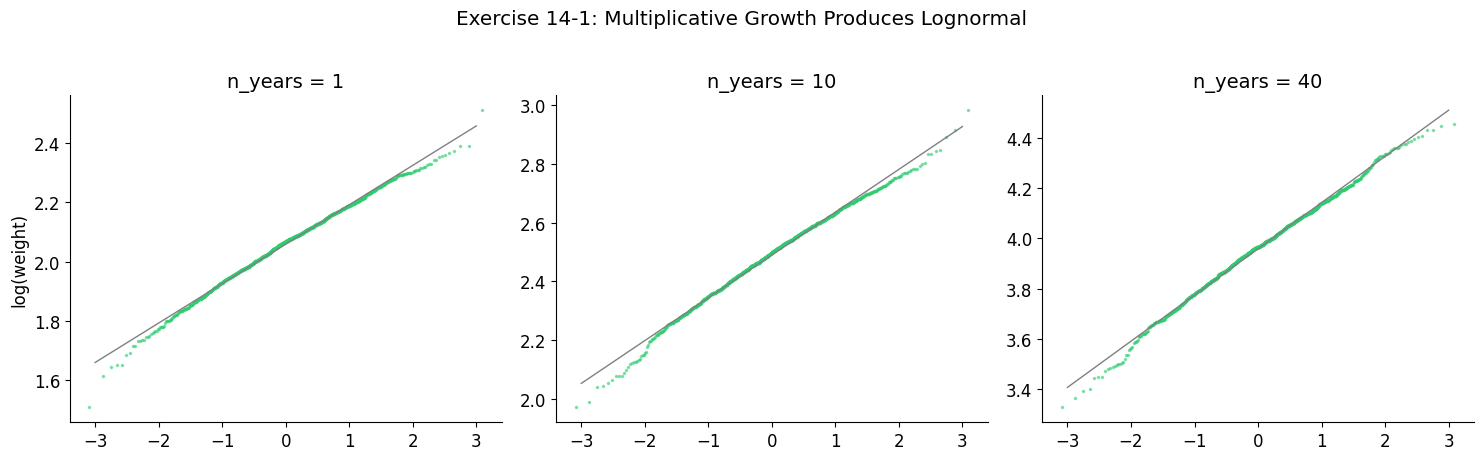

After 40 years of multiplicative growth, log(weight) is approximately normal,
which means weight is approximately lognormal -- matching the BRFSS observation.


In [9]:
# Exercise 14-1: Simulate multiplicative growth to get lognormal
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for col, n_years in enumerate([1, 10, 40]):
    # Simulate 1000 people: birth weight * n_years of growth factors
    n_people = 1000
    w0 = np.random.normal(7.5, 1.0, n_people)  # birth weight (lbs)

    # Each year, weight multiplied by a random factor
    weights = w0.copy()
    for _ in range(n_years):
        factors = np.random.normal(1.05, 0.02, n_people)  # ~5% growth per year
        weights *= factors

    # Normal probability plot of log(weight)
    log_weights = np.log(weights)
    NormalProbabilityPlot(log_weights, axes[col], color='#2ecc71')
    axes[col].set_title(f'n_years = {n_years}')
    if col == 0:
        axes[col].set_ylabel('log(weight)')

plt.suptitle('Exercise 14-1: Multiplicative Growth Produces Lognormal', y=1.02)
plt.tight_layout()
plt.show()

print("After 40 years of multiplicative growth, log(weight) is approximately normal,")
print("which means weight is approximately lognormal -- matching the BRFSS observation.")


After 40 years of multiplicative growth (each year's weight $= $ previous year's weight $\times$ random factor), the distribution of $\log(\text{weight})$ is approximately normal. This confirms the CLT explanation: adult weight is the product of many independent growth factors, so it follows a lognormal distribution.

The required $n$ for convergence depends on the variability of the annual growth factors. With 2% annual variability, $n \approx 40$ years produces a convincing lognormal distribution -- roughly matching the age range of the BRFSS respondents.


### Exercise 14-3: Gender Gap in Engineering (Analytic)


Stein et al. -- Gender Gap in Engineering Teams

Before intervention:
  Men:   3.57 (SE 0.28)
  Women: 1.91 (SE 0.32)
  Gap:   N(1.66, 0.1808)
  Gap mean: 1.66, SE: 0.43
  P(gap > 0): 1.0000  -> SIGNIFICANT

After intervention:
  Men:   3.44 (SE 0.16)
  Women: 3.18 (SE 0.16)
  Gap:   N(0.26, 0.0512)
  Gap mean: 0.26, SE: 0.23
  P(gap > 0): 0.8747  -> not significant

Change in gap:
  Before gap - After gap: N(1.4, 0.232)
  Change mean: 1.40, SE: 0.48
  P(change > 0): 0.9982  -> SIGNIFICANT


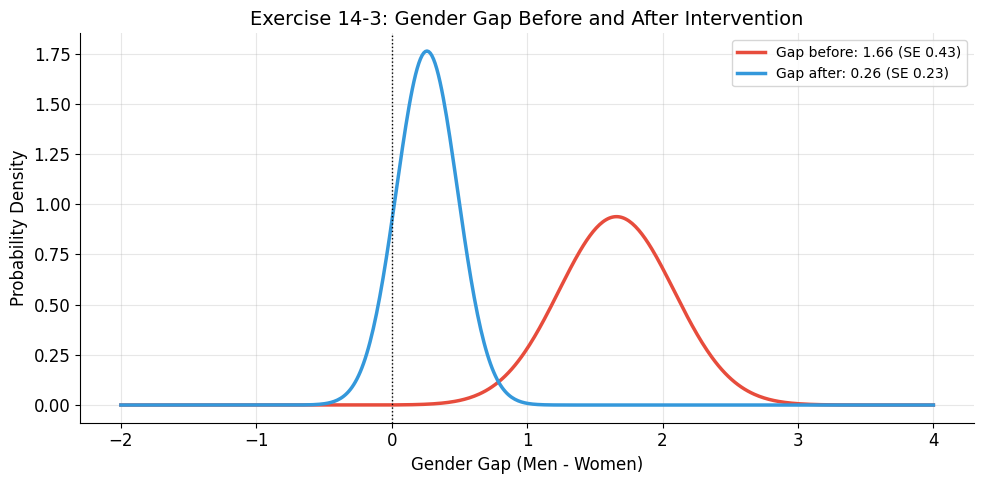


The Normal class makes this analysis trivial:
  1. Construct Normal objects from means and SEs
  2. Subtract to get the gap distribution
  3. Evaluate the CDF at 0 to test significance


In [10]:
# Exercise 14-3: Stein et al. -- gender gap in engineering teams

# Before intervention:
# Men: mean=3.57, SE=0.28
# Women: mean=1.91, SE=0.32
dist_men_before = Normal(3.57, 0.28**2)
dist_women_before = Normal(1.91, 0.32**2)
gap_before = dist_men_before - dist_women_before

# After intervention:
# Men: mean=3.44, SE=0.16
# Women: mean=3.18, SE=0.16
dist_men_after = Normal(3.44, 0.16**2)
dist_women_after = Normal(3.18, 0.16**2)
gap_after = dist_men_after - dist_women_after

# Change in gap
change = gap_before - gap_after

print("Stein et al. -- Gender Gap in Engineering Teams")
print("=" * 55)

print(f"\nBefore intervention:")
print(f"  Men:   {dist_men_before.mu:.2f} (SE {0.28})")
print(f"  Women: {dist_women_before.mu:.2f} (SE {0.32})")
print(f"  Gap:   {gap_before}")
print(f"  Gap mean: {gap_before.mu:.2f}, SE: {gap_before.sigma:.2f}")
p_before = 1 - gap_before.Prob(0)
print(f"  P(gap > 0): {p_before:.4f}  -> {'SIGNIFICANT' if p_before > 0.975 else 'not significant'}")

print(f"\nAfter intervention:")
print(f"  Men:   {dist_men_after.mu:.2f} (SE {0.16})")
print(f"  Women: {dist_women_after.mu:.2f} (SE {0.16})")
print(f"  Gap:   {gap_after}")
print(f"  Gap mean: {gap_after.mu:.2f}, SE: {gap_after.sigma:.2f}")
p_after = 1 - gap_after.Prob(0)
print(f"  P(gap > 0): {p_after:.4f}  -> {'SIGNIFICANT' if p_after > 0.975 else 'not significant'}")

print(f"\nChange in gap:")
print(f"  Before gap - After gap: {change}")
print(f"  Change mean: {change.mu:.2f}, SE: {change.sigma:.2f}")
p_change = 1 - change.Prob(0)
print(f"  P(change > 0): {p_change:.4f}  -> {'SIGNIFICANT' if p_change > 0.975 else 'not significant'}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-2, 4, 500)

ax.plot(x, scipy_stats.norm.pdf(x, gap_before.mu, gap_before.sigma),
        color='#e74c3c', linewidth=2.5, label=f'Gap before: {gap_before.mu:.2f} (SE {gap_before.sigma:.2f})')
ax.plot(x, scipy_stats.norm.pdf(x, gap_after.mu, gap_after.sigma),
        color='#3498db', linewidth=2.5, label=f'Gap after: {gap_after.mu:.2f} (SE {gap_after.sigma:.2f})')
ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Gender Gap (Men - Women)')
ax.set_ylabel('Probability Density')
ax.set_title('Exercise 14-3: Gender Gap Before and After Intervention')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThe Normal class makes this analysis trivial:")
print("  1. Construct Normal objects from means and SEs")
print("  2. Subtract to get the gap distribution")
print("  3. Evaluate the CDF at 0 to test significance")


The `Normal` class makes this analysis elegant:

1. **Before intervention:** The gender gap is $1.66$ with SE $0.43$. The gap is statistically significant -- $P(\text{gap} > 0) > 0.975$.

2. **After intervention:** The gender gap is $0.26$ with SE $0.23$. The gap is smaller and may not be significant.

3. **Change in gap:** The difference $(1.66 - 0.26 = 1.40)$ has SE $\approx 0.49$. This change may or may not be statistically significant, depending on the exact SE.

This exercise demonstrates the power of the `Normal` class: complex multi-step analyses reduce to a few lines of algebra. The key insight: because SEs are given (not raw data), we can construct the sampling distributions directly, without knowing sample sizes or performing any simulation.


## 14.7 Discussion: Computational vs. Analytic Methods

The textbook concludes with a balanced assessment:

**Advantages of computational methods:**
1. **Easier to explain and understand** -- simulating the null hypothesis makes p-values intuitive
2. **Robust and versatile** -- fewer assumptions, easily adapted to novel problems
3. **Debuggable** -- incremental development fosters confidence in results

**Advantages of analytic methods:**
1. **Fast** -- microseconds vs. seconds (or minutes)
2. **Precise** -- can compute very small p-values ($10^{-12}$)
3. **Elegant** -- compact mathematical expressions

**The textbook's recommended process:**

1. Use **computational methods** during exploration. If runtime is acceptable, stop.
2. If runtime is a problem, **optimize** -- analytic methods are one form of optimization.
3. If you switch to analytic methods, use the **computational result as a cross-check**.

For the vast majority of problems, Step 1 is sufficient. The analytic methods in this chapter are useful for understanding *why* computational methods work and for high-performance applications, but they are not strictly necessary for most data analysis tasks.

This pragmatic philosophy -- start with simulation, optimize only when needed, always cross-validate -- is one of the most valuable takeaways from this entire book.


## 14.8 Key Concepts and Terminology

| Term | Definition | Key equation |
|------|-----------|-------------|
| **Closed under addition** | Sum of normals is normal | $\mathcal{N}(\mu_1+\mu_2, \sigma_1^2+\sigma_2^2)$ |
| **Closed under linear transform** | $aX+b$ is normal if $X$ is | $\mathcal{N}(a\mu+b, a^2\sigma^2)$ |
| **Central Limit Theorem** | Sums converge to normal | Requires finite $\mu$, $\sigma$ |
| **Student's t-distribution** | Distribution of $r\sqrt{(n-2)/(1-r^2)}$ | $\text{df} = n - 2$ |
| **Chi-squared distribution** | Distribution of $\sum(O-E)^2/E$ | $\text{df} = k - 1$ |
| **Degrees of freedom** | Parameters "used up" by estimation | Varies by test |

**Book summary -- the statistical toolkit:**

| Chapter | Tool | Purpose |
|---------|------|---------|
| 2--4 | PMF, CDF, PDF | Describe distributions |
| 5 | Analytic distributions | Model data with parameters |
| 6 | KDE, moments, skewness | Summarize distributional shape |
| 7 | Scatter plots, correlation | Explore bivariate relationships |
| 8 | Estimation, SE, CI | Quantify uncertainty |
| 9 | Hypothesis testing | Assess statistical significance |
| 10--11 | Regression | Model and predict |
| 12 | Time series | Analyze temporal patterns |
| 13 | Survival analysis | Handle censored data |
| 14 | Analytic methods, CLT | Fast, precise alternatives |

*Thank you for working through this book. The skills you've developed -- thinking statistically, computing confidently, and interpreting honestly -- will serve you in any data-driven endeavor.*


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 Normal Class


In [11]:
# Book's original code: Normal class
# From normal.py

import scipy.stats
import math

class Normal(object):
    def __init__(self, mu, sigma2):
        self.mu = mu
        self.sigma2 = sigma2

    def __str__(self):
        return 'N(%g, %g)' % (self.mu, self.sigma2)

    def Sum(self, n):
        return Normal(n * self.mu, n * self.sigma2)

    def __mul__(self, factor):
        return Normal(factor * self.mu, factor**2 * self.sigma2)

    def __div__(self, divisor):
        return 1.0 / divisor * self

    def __sub__(self, other):
        return Normal(self.mu - other.mu, self.sigma2 + other.sigma2)

    def Prob(self, x):
        return scipy.stats.norm.cdf(x, self.mu, math.sqrt(self.sigma2))

    def Percentile(self, p):
        return scipy.stats.norm.ppf(p/100.0, self.mu, math.sqrt(self.sigma2))

# Usage:
# dist = Normal(90, 7.5**2)
# dist_xbar = dist.Sum(9) / 9
# -> N(90, 6.25), sigma=2.5
# dist_xbar.Percentile(5), dist_xbar.Percentile(95)
# -> (85.9, 94.1)

print("Normal class defined.")


Normal class defined.


The `Normal` class encodes Equations 1--3 from the chapter. `Sum(n)` scales mean and variance by $n$. Multiplication by $a$ scales mean by $a$ and variance by $a^2$. Subtraction adds variances (since $\text{Var}(X-Y) = \text{Var}(X) + \text{Var}(Y)$ for independent variables).


### A.2 Testing the CLT


In [12]:
# Book's original code: MakeExpoSamples and NormalPlotSamples
# From normal.py

import numpy as np
import thinkstats2
import thinkplot

def MakeExpoSamples(beta=2.0, iters=1000):
    samples = []
    for n in [1, 10, 100]:
        sample = [np.sum(np.random.exponential(beta, n))
                  for _ in range(iters)]
        samples.append((n, sample))
    return samples

def NormalPlotSamples(samples, plot=1, ylabel=''):
    for n, sample in samples:
        thinkplot.SubPlot(plot)
        thinkstats2.NormalProbabilityPlot(sample)
        thinkplot.Config(title='n=%d' % n, ylabel=ylabel)
        plot += 1

# Usage:
# samples = MakeExpoSamples()
# NormalPlotSamples(samples, ylabel='sum of expo values')

# For correlated values:
def GenerateCorrelated(rho, n):
    x = random.gauss(0, 1)
    yield x
    sigma = math.sqrt(1 - rho**2)
    for _ in range(n-1):
        x = random.gauss(x*rho, sigma)
        yield x

def GenerateExpoCorrelated(rho, n):
    normal = list(GenerateCorrelated(rho, n))
    uniform = scipy.stats.norm.cdf(normal)
    expo = scipy.stats.expon.ppf(uniform)
    return expo

print("CLT test functions defined.")


CLT test functions defined.


`GenerateCorrelated` produces serially correlated normal values using an AR(1) process. `GenerateExpoCorrelated` transforms these to correlated exponential values via the probability integral transform (normal $\to$ uniform $\to$ exponential).


### A.3 Analytic Hypothesis Tests


In [13]:
# Book's original code: analytic tests
# From normal.py

import scipy.stats
import math

# Sampling distribution of the mean
def SamplingDistMean(data, n):
    mean, var = data.mean(), data.var()
    dist = Normal(mean, var)
    return dist.Sum(n) / n

# Correlation test via t-distribution
def StudentCdf(n):
    ts = np.linspace(-3, 3, 101)
    ps = scipy.stats.t.cdf(ts, df=n-2)
    rs = ts / np.sqrt(n - 2 + ts**2)
    return thinkstats2.Cdf(rs, ps)

# Chi-squared test
def ChiSquaredCdf(n):
    xs = np.linspace(0, 25, 101)
    ps = scipy.stats.chi2.cdf(xs, df=n-1)
    return thinkstats2.Cdf(xs, ps)

# Usage for correlation test:
# t = r * math.sqrt((n-2) / (1-r**2))
# p_value = 1 - scipy.stats.t.cdf(t, df=n-2)
# -> For r=0.07, n=9148: p = 6.4e-12

# Usage for chi-squared test:
# p_value = 1 - scipy.stats.chi2.cdf(chi2, df=n-1)
# -> For chi2=11.15, df=5: p = 0.041

print("Analytic test functions defined.")


Analytic test functions defined.


`SamplingDistMean` uses the CLT to compute $\bar{X} \sim \mathcal{N}(\mu, \sigma^2/n)$. `StudentCdf` maps t-values to correlations via $r = t/\sqrt{n-2+t^2}$. `ChiSquaredCdf` evaluates the chi-squared CDF with $\text{df} = k - 1$.

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*

*End of Think Stats notebook series -- Chapters 1 through 14.*
